In [575]:
import pandas as pd

In [576]:
df = pd.read_csv("zepto_v2(in).csv")


In [577]:
df

,Category,name,mrp,discountPercent,availableQuantity,discountedSellingPrice,weightInGms,outOfStock,quantity
0,Fruits & Vegetables,Onion,2500,16,3,2100,1000,False,1
1,Fruits & Vegetables,Tomato Hybrid,4200,16,3,3500,1000,False,1
2,Fruits & Vegetables,Tender Coconut,5100,15,3,4300,58,False,1
3,Fruits & Vegetables,Coriander Leaves,2000,15,3,1700,100,False,100
4,Fruits & Vegetables,Ladies Finger,1400,14,3,1200,250,False,250
...,...,...,...,...,...,...,...,...,...
3727,Health & Hygiene,Stayfree Secure Dry Cover Extra Large Sanitary...,4200,2,0,4100,406,True,7
3728,Health & Hygiene,Dabur Honitus Herbal Cough Remedy Ayurvedic Syrup,10500,15,0,8900,100,True,100
3729,Health & Hygiene,Whisper Bindazzz Night Sanitary Pads XL Plus,18500,0,0,18500,870,True,15
3730,Health & Hygiene,Fine Life Cotton Balls,6000,0,0,6000,50,True,50


In [578]:
df.columns

Index(['Category', 'name', 'mrp', 'discountPercent', 'availableQuantity',
       'discountedSellingPrice', 'weightInGms', 'outOfStock', 'quantity'],
      dtype='object')

In [579]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Category                3732 non-null   object
 1   name                    3732 non-null   object
 2   mrp                     3732 non-null   int64 
 3   discountPercent         3732 non-null   int64 
 4   availableQuantity       3732 non-null   int64 
 5   discountedSellingPrice  3732 non-null   int64 
 6   weightInGms             3732 non-null   int64 
 7   outOfStock              3732 non-null   bool  
 8   quantity                3732 non-null   int64 
dtypes: bool(1), int64(6), object(2)
memory usage: 237.0+ KB


In [580]:
df.shape

(3732, 9)

In [581]:
# Add sku_id as an auto-increment primary key
df.insert(0, "sku_id", range(1, len(df) + 1))


In [582]:
print(df.head())
print(df["sku_id"].is_unique)  # Should return True


   sku_id             Category              name   mrp  discountPercent  \
0       1  Fruits & Vegetables             Onion  2500               16   
1       2  Fruits & Vegetables     Tomato Hybrid  4200               16   
2       3  Fruits & Vegetables    Tender Coconut  5100               15   
3       4  Fruits & Vegetables  Coriander Leaves  2000               15   
4       5  Fruits & Vegetables    Ladies Finger   1400               14   

   availableQuantity  discountedSellingPrice  weightInGms  outOfStock  \
0                  3                    2100         1000       False   
1                  3                    3500         1000       False   
2                  3                    4300           58       False   
3                  3                    1700          100       False   
4                  3                    1200          250       False   

   quantity  
0         1  
1         1  
2         1  
3       100  
4       250  
True


In [583]:
df.columns

Index(['sku_id', 'Category', 'name', 'mrp', 'discountPercent',
       'availableQuantity', 'discountedSellingPrice', 'weightInGms',
       'outOfStock', 'quantity'],
      dtype='object')

# Data Cleaning

In [584]:
#Data cleaning
# Convert price columns from paise to rupees
df["mrp"] = df["mrp"] / 100
df["discountedSellingPrice"] = df["discountedSellingPrice"] / 100


In [585]:
# Ensure float type
df["mrp"] = df["mrp"].astype(float)
df["discountedSellingPrice"] = df["discountedSellingPrice"].astype(float)

In [586]:
# Validate discount logic
invalid_price_rows = df[df["discountedSellingPrice"] > df["mrp"]]

In [587]:
#4. Basic Data Exploration

In [588]:
# Dataset overview
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3732 entries, 0 to 3731
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sku_id                  3732 non-null   int64  
 1   Category                3732 non-null   object 
 2   name                    3732 non-null   object 
 3   mrp                     3732 non-null   float64
 4   discountPercent         3732 non-null   int64  
 5   availableQuantity       3732 non-null   int64  
 6   discountedSellingPrice  3732 non-null   float64
 7   weightInGms             3732 non-null   int64  
 8   outOfStock              3732 non-null   bool   
 9   quantity                3732 non-null   int64  
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 266.2+ KB
None


In [589]:
# Total rows
print("Total rows:", len(df))

Total rows: 3732


In [590]:
# Sample data
print(df.head(10))

   sku_id             Category              name   mrp  discountPercent  \
0       1  Fruits & Vegetables             Onion  25.0               16   
1       2  Fruits & Vegetables     Tomato Hybrid  42.0               16   
2       3  Fruits & Vegetables    Tender Coconut  51.0               15   
3       4  Fruits & Vegetables  Coriander Leaves  20.0               15   
4       5  Fruits & Vegetables    Ladies Finger   14.0               14   
5       6  Fruits & Vegetables            Potato  35.0               17   
6       7  Fruits & Vegetables             Lemon  75.0               16   
7       8  Fruits & Vegetables       Watermelon   58.0               15   
8       9  Fruits & Vegetables   Capsicum Green   23.0               17   
9      10  Fruits & Vegetables     Chilli Green   19.0               15   

   availableQuantity  discountedSellingPrice  weightInGms  outOfStock  \
0                  3                    21.0         1000       False   
1                  3        

# Data Quality Checks

In [591]:
# Duplicate products by name
duplicate_products = (
    df.groupby("name")
    .size()
    .reset_index(name="duplicate_count")
    .query("duplicate_count > 1")
)


In [592]:
# Missing values in key columns
missing_values = df[
    df[[
        "name", "Category", "mrp", "discountPercent",
        "discountedSellingPrice", "weightInGms",
        "availableQuantity", "outOfStock", "quantity"
    ]].isnull().any(axis=1)
]


# EXPLORATORY DATA ANALYSIS (EDA)

# 1.Category & Product Analysis

In [593]:
# Unique categories
unique_categories = sorted(df["Category"].dropna().unique())

In [594]:
# Product count by category
products_by_category = (
    df.groupby("Category")
    .size()
    .reset_index(name="product_count")
    .sort_values(by="product_count", ascending=False)
)

In [595]:
# Products with multiple SKUs
multi_sku_products = (
    df.groupby("name")["sku_id"]
    .count()
    .reset_index(name="Number of SKUs")
    .query("`Number of SKUs` > 1")
    .sort_values(by="Number of SKUs", ascending=False)
)

# 2. Stock Analysis

In [596]:
# In stock vs out of stock
stock_distribution = df["outOfStock"].value_counts().reset_index()
stock_distribution.columns = ["outOfStock", "count"]

In [597]:
# Low stock products
low_stock_products = df[df["availableQuantity"] < 10].sort_values("availableQuantity")


In [598]:
# Out-of-stock products by category
out_of_stock_by_category = (
    df[df["outOfStock"] == True]
    .groupby("Category")
    .size()
    .reset_index(name="out_of_stock_count")
    .sort_values(by="out_of_stock_count", ascending=False)
)

# 3. Price & Discount Analysis


In [599]:
price_stats = df["mrp"].describe()
discount_stats = df["discountPercent"].describe()

In [600]:
# High discount products
top_discounted_products = (
    df[["name", "Category", "discountPercent"]]
    .sort_values(by="discountPercent", ascending=False)
    .head(10)
)

In [601]:
# Products without discount
no_discount_products = df[df["mrp"] == df["discountedSellingPrice"]]

In [602]:
# Products with discount > 30%
high_discount_count = (df["discountPercent"] > 30).sum()

In [603]:
# Average discount by category
avg_discount_by_category = (
    df.groupby("Category")["discountPercent"]
    .mean()
    .reset_index()
    .sort_values(by="discountPercent", ascending=False)
)

# 4. Weight & Quantity Analysis


In [604]:
# Weight stats
weight_stats = df["weightInGms"].describe()

In [605]:
# Weight category
df["weight_category"] = df["weightInGms"].apply(
    lambda x: "Small Pack" if x <= 250 else "Medium Pack" if x <= 1000 else "Large Pack"
)

In [606]:
weight_category_distribution = weight_category_distribution.rename(
    columns={
        "product_count": "weight_category",
        "count": "product_count"
    }
)


In [607]:
# Quantity distribution
quantity_distribution = (
    df.groupby("quantity")
    .size()
    .reset_index(name="product_count")
    .sort_values(by="quantity", ascending=False)
)


In [608]:
#Category Weight Distribution
category_weight_distribution = (
    df
    .groupby(["Category", "weight_category"])
    .size()
    .reset_index(name="product_count")
)


In [609]:

# 10. Value for Money
df["savings"] = df["mrp"] - df["discountedSellingPrice"]

top_savings_products = (
    df[["name", "Category", "mrp", "discountedSellingPrice", "savings"]]
    .sort_values(by="savings", ascending=False)
    .head(10)
)

In [610]:
#11. Overall Summary

summary = {
    "total_products": len(df),
    "total_categories": df["Category"].nunique(),
    "average_discount": round(df["discountPercent"].mean(), 2),
    "out_of_stock_products": df["outOfStock"].sum()
}

categories_above_50 = (
    df.groupby("Category")
    .size()
    .reset_index(name="product_count")
    .query("product_count > 50")
)

top_available_quantity = (
    df[["name", "availableQuantity"]]
    .sort_values(by="availableQuantity", ascending=False)
    .head(10)
)

# Visualizations

In [611]:
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [612]:
import matplotlib.pyplot as plt
import seaborn as sns

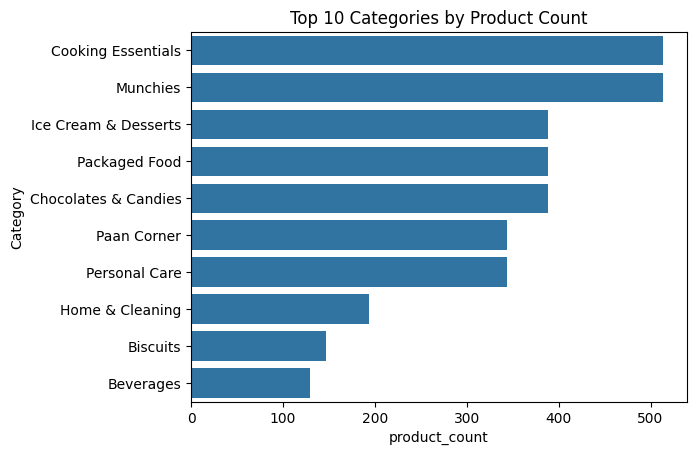

In [613]:
plt.figure()
sns.barplot(data=products_by_category.head(10), x="product_count", y="Category")
plt.title("Top 10 Categories by Product Count")
plt.show()

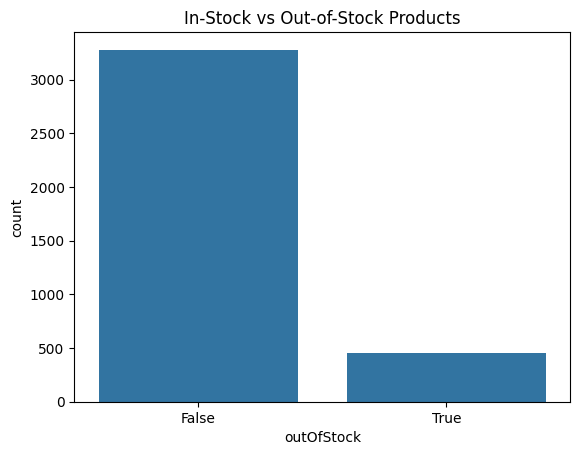

In [614]:
plt.figure()
sns.countplot(data=df, x="outOfStock")
plt.title("In-Stock vs Out-of-Stock Products")
plt.show()

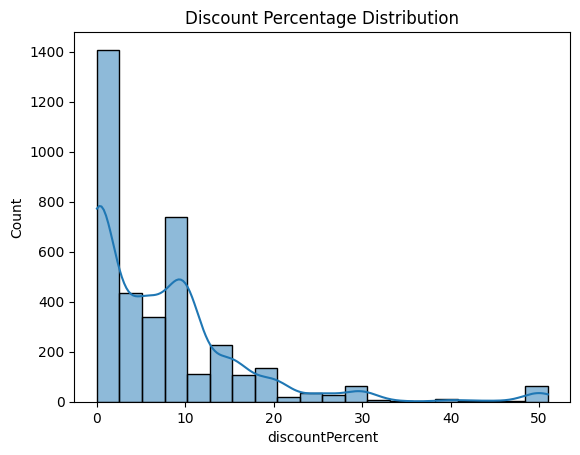

In [615]:
plt.figure()
sns.histplot(df["discountPercent"], bins=20, kde=True)
plt.title("Discount Percentage Distribution")
plt.show()

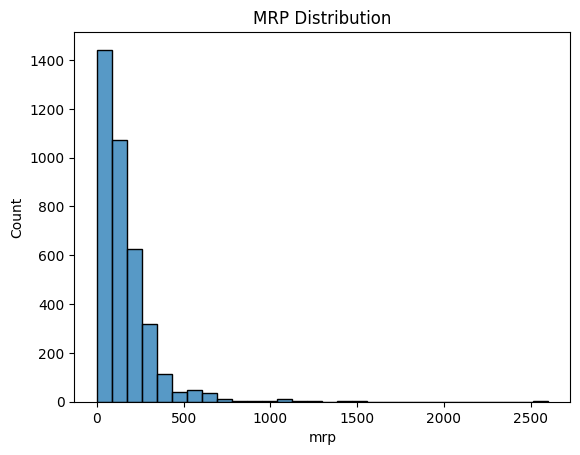

In [616]:
plt.figure()
sns.histplot(df["mrp"], bins=30)
plt.title("MRP Distribution")
plt.show()

In [617]:
print(weight_category_distribution.columns)

Index(['weight_category', 'weight_category'], dtype='object')


In [618]:
print(weight_category_distribution.head())


   weight_category  weight_category
0       Small Pack             2115
1      Medium Pack             1491
2       Large Pack              126


In [619]:
weight_category_distribution.columns = ["weight_category", "product_count"]


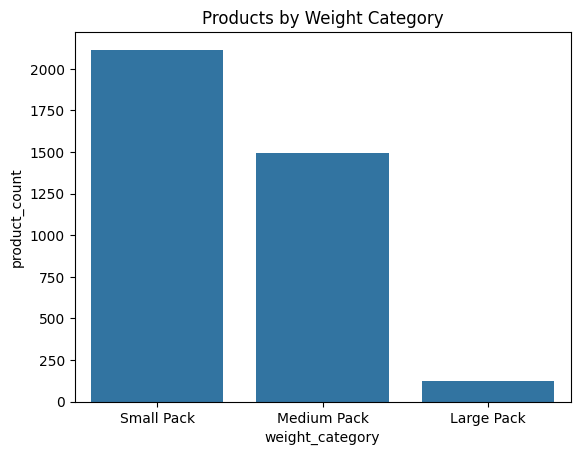

In [620]:
plt.figure()
sns.barplot(data=weight_category_distribution, x="weight_category", y="product_count")
plt.title("Products by Weight Category")
plt.show()

In [621]:
print(category_weight_distribution.columns)

Index(['Category', 'weight_category', 'product_count'], dtype='object')


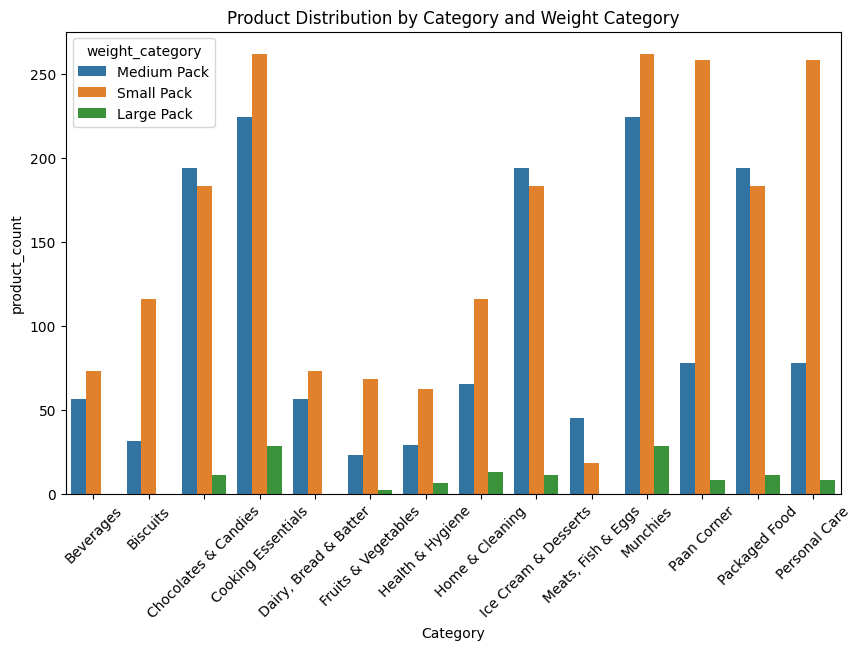

In [622]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=category_weight_distribution,
    x="Category",
    y="product_count",
    hue="weight_category"
)
plt.title("Product Distribution by Category and Weight Category")
plt.xticks(rotation=45)
plt.show()
